# SOB4ES - Modelo de Regresion (Ridge)
### CRISP-ML(Q) - Fase 3 y 4: Desarrollo y evaluacion de los modelos

Este notebook recorre el ciclo de vida completo del modelo de regresion lineal regularizada (Ridge Regression).

Se usa Ridge en lugar de regresion lineal simple porque regulariza los coeficientes (penalizacion L2), lo que mejora la estabilidad cuando hay variables correlacionadas o cuando el numero de predictores es alto.

**Datasets utilizados:**
- `train.csv` - Entrenamiento del modelo (70 % del total, estratificado por pais)
- `test.csv`  - Busqueda de hiperparametros y validacion cruzada (15 %)
- `eval.csv`  - Evaluacion final e imparcial del rendimiento (15 %)

**Estructura del notebook:**
1. Configuracion: importaciones y parametros globales.
2. Carga de datos: se cargan los tres splits pre-generados.
3. Tuning: busqueda del valor optimo de regularizacion alpha.
4. Validacion cruzada: evaluacion de robustez.
5. Importancia de variables: coeficientes y permutation importance.
6. Produccion: entrenamiento final y exportacion de modelos.
7. Evaluacion final: rendimiento real sobre `eval.csv`.

---
## 1.- Configuracion del entorno

En esta sección del notebook importaremos todas las librerías necesarias como también realizaremos las configuraciones iniciales.


In [1]:
import os
import time
import warnings
import joblib
import pandas as pd
import numpy as np
import itertools
from pathlib import Path

from sklearn.linear_model import Ridge
from sklearn.model_selection import RandomizedSearchCV, cross_validate, RepeatedKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ignoramos los warnings
warnings.filterwarnings('ignore')

DATA_DIR   = 'input/'
MODELS_DIR = 'output/models/reg/'
Path(MODELS_DIR).mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 128

TARGETS = [
    # Shannon diversity index
    'nematode_shannon_z',
    'macro_shannon_z',
    'earthworm_shannon_z',
    'orib_shannon_z',
    'meso_shannon_z',
    'coll_shannon_z',
    'bac_shannon_z',
    'fun_shannon_z',
    'euk_shannon_z',
    'oomy_shannon_z',
    'cerc_shannon_z',
    # Richness
    'macro_order_richness_z',
    'earthworm_richness_z',
    'orib_species_richness_z',
    'meso_species_richness_z',
    'coll_species_richness_z',
    'bac_asv_richness_z',
    'fun_asv_richness_z',
    'euk_asv_richness_z',
    'oomy_asv_richness_z',
    'cerc_asv_richness_z'
]


FEATURES_AUTORIZADAS = [
    'total_plant_cover_z',
    'clay_content_z',
    'silt_content_z',
    'sand_content_z',
    'aggregate_stability_z',
    'bulk_density_z',
    'soil_moisture_z',
    'as_z',
    'cu_z',
    'k_z',
    'mo_z',
    'ni_z',
    'p_z',
    'pb_z',
    'zn_z',
    'soil_ph_z',
    'plot_total_organic_c_z',
    'plot_total_n_z',
    'gee_temp_media_C_z',
    'gee_humedad_rel_pct_z',
    'gee_ndvi_verano_z',
    'dem_elevacion_m_z',
    'dem_pendiente_deg_z',
    'dem_orientacion_deg_z',
    'eu_clay_content_z',
    'eu_sand_content_z',
    'eu_silt_content_z',
    'eu_water_holding_capacity_z',
    'eu_cn_ratio_z',
    'eu_p_z',
    'eu_ph_z',
    'eu_as_z',
    'eu_organic_carbon_octop_z',
    'eu_zn_z'
]


print('Librerias y variables cargadas correctamente...')


# Paleta de colores unificada
PALETTE = {
    'blue':         '#7FA6C9',
    'blue_light':   '#AAD0F1',
    'green':        '#7FC8A9',
    'green_light':  '#BEE6D3',
    'purple':       '#A98FC7',
    'purple_light': '#D6C7EA',
    'gray':         '#9B9B9B',
    'gray_dark':    '#5C5C5C',
}

# Secuencia ciclica para graficos con N series/categorias (N puede superar 6)
PALETTE_CYCLE = [PALETTE['blue'], PALETTE['green'], PALETTE['purple'],
                 PALETTE['blue_light'], PALETTE['green_light'], PALETTE['purple_light']]

def palette_cycle(n):
    """Devuelve una lista de n colores repitiendo PALETTE_CYCLE si hace falta."""
    return list(itertools.islice(itertools.cycle(PALETTE_CYCLE), n))

# Colormap secuencial (blanco -> azul -> morado) para heatmaps/matrices de confusion
PALETTE_CMAP = LinearSegmentedColormap.from_list(
    'sob4es_palette', ['#FFFFFF', PALETTE['purple_light'], PALETTE['purple']]
)

Librerias y variables cargadas correctamente...


In [2]:
# Ajuste automatico de n_jobs segun los nucleos disponibles
# Evita saturar la maquina (todos los procesos a la vez con n_jobs=-1)
import os

def get_n_jobs(fraccion=0.75, reserva=1):
    """Calcula un n_jobs seguro dejando al menos `reserva` nucleos libres
    para que el sistema no se vuelva inutilizable durante la ejecucion."""
    n_cpu = os.cpu_count() or 1
    n_usar = max(1, min(int(n_cpu * fraccion), n_cpu - reserva))
    return n_usar

N_JOBS = get_n_jobs()
print(f'Nucleos disponibles: {os.cpu_count()} | n_jobs asignado: {N_JOBS}')

Nucleos disponibles: 20 | n_jobs asignado: 15


## 2.- Carga de datos

Se cargan los tres datasets pre-generados a partir de la division 70/15/15 estratificada por pais.

| Archivo    | Uso                                      | Filas aprox. |
|------------|------------------------------------------|--------------|
| `train.csv`| Ajuste del modelo                        | 299          |
| `test.csv` | Tuning de hiperparametros / Val. cruzada | 64           |
| `eval.csv` | Evaluacion final imparcial               | 65           |

El dataset `eval.csv` no se utiliza hasta la sección 7 para garantizar una estimacion imparcial del rendimiento.

In [3]:
def cargar_csv(ruta, nombre):
    """Carga un CSV (sep=',' o ';') y valida las columnas necesarias."""
    if not os.path.exists(ruta):
        raise FileNotFoundError(f"No se encontro el archivo: {ruta}")
    try:
        df = pd.read_csv(ruta, sep=',')
        if len(df.columns) < 5:
            df = pd.read_csv(ruta, sep=';')
    except Exception:
        df = pd.read_csv(ruta, sep=';')
    print(f"  {nombre}: {df.shape[0]} filas x {df.shape[1]} columnas")
    return df

print("Cargando datasets...")
df_train = cargar_csv(os.path.join(DATA_DIR, 'train.csv'), 'train.csv')
df_test  = cargar_csv(os.path.join(DATA_DIR, 'test.csv'),  'test.csv')
df_eval  = cargar_csv(os.path.join(DATA_DIR, 'eval.csv'),  'eval.csv')

X_train = df_train[FEATURES_AUTORIZADAS]
y_train = df_train[TARGETS]

X_test  = df_test[FEATURES_AUTORIZADAS]
y_test  = df_test[TARGETS]

X_eval  = df_eval[FEATURES_AUTORIZADAS]   # no se usa hasta la seccion 7
y_eval  = df_eval[TARGETS]               # no se usa hasta la seccion 7

print(f"\nDatasets cargados...")
print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}  |  X_eval: {X_eval.shape}")
print(f"y_train: {y_train.shape}  |  y_test: {y_test.shape}  |  y_eval: {y_eval.shape}")

Cargando datasets...
  train.csv: 299 filas x 71 columnas
  test.csv: 64 filas x 71 columnas
  eval.csv: 65 filas x 71 columnas

Datasets cargados...
X_train: (299, 34)  |  X_test: (64, 34)  |  X_eval: (65, 34)
y_train: (299, 21)  |  y_test: (64, 21)  |  y_eval: (65, 21)


## 3.- Busqueda de hiperparametros (Tuning)

En Ridge Regression el principal hiperparametro es `alpha`, que controla la intensidad de la regularizacion:
- `alpha` cercano a 0: comportamiento similar a la regresion lineal ordinaria (sin regularizacion).
- `alpha` alto: coeficientes mas penalizados, modelo mas simple y resistente al sobreajuste.

Tambien se exploran `fit_intercept` y el `solver` numerico. La busqueda se realiza exclusivamente sobre `X_train`.

In [4]:
import time
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

# SECCIÓN 3: Tuning de hiperparámetros para CADA target
print("Iniciando búsqueda de hiperparámetros para cada target...")
print("Aplicando GridSearchCV y filtro estricto de estabilidad (gap Train-CV <= 0.10)...\n")

idx = 0 # Contador auxiliar

global_start = time.time()

REG_OPTIMAL_PARAMS_PER_TARGET = {}

# Definimos un espacio exhaustivo con alphas masivos para targets sin señal predictiva
param_grid = {
	'alpha':         np.logspace(-1, 8, 120), # Exploración milimétrica hasta 10^8
	'fit_intercept': [True, False],
	'solver':        ['auto', 'cholesky', 'lsqr'] # Solvers altamente estables para matrices con alphas grandes
}

for target_col in TARGETS:
    t0 = time.time()
    y = y_train[target_col].values
    idx += 1
    
    search = GridSearchCV(
        estimator=Ridge(random_state=RANDOM_STATE),
        param_grid=param_grid,
        cv=5,
        scoring='r2',
        n_jobs=N_JOBS, 
        return_train_score=True
    )
    
    search.fit(X_train, y)
    
    df_res = pd.DataFrame(search.cv_results_)
    df_res['gap'] = df_res['mean_train_score'] - df_res['mean_test_score']
    
    # Ajustamos el umbral a 0.10 para asegurar que quede bien lejos del límite de sobreajuste
    UMBRAL_GAP = 0.10
    soluciones_estables = df_res[df_res['gap'] <= UMBRAL_GAP]
    
    if not soluciones_estables.empty:
        # Entre las que no sobreajustan, elegimos la que tenga mejor rendimiento en validación
        idx_optimo = soluciones_estables['mean_test_score'].idxmax()
    else:
        # Si el target es crítico y todo sobreajusta, forzamos el alpha más alto para desplazar el gap a 0
        idx_optimo = df_res['gap'].idxmin()
        
    mejores_params = df_res.loc[idx_optimo, 'params']
    mejor_r2_cv = df_res.loc[idx_optimo, 'mean_test_score']
    gap_elegido = df_res.loc[idx_optimo, 'gap']
    
    REG_OPTIMAL_PARAMS_PER_TARGET[target_col] = mejores_params
    
    print(f"[{idx:2d}/{len(TARGETS)}] | [{target_col:<25}] | R2 CV: {mejor_r2_cv:.4f} | Gap Tuning: {gap_elegido:.4f} | Alpha: {mejores_params['alpha']:.2f} | Tiempo: {time.time()-t0:>4.1f}s")

print(f"\nTuning completado en {(time.time() - global_start) / 60:.1f} minutos.\n")

Iniciando búsqueda de hiperparámetros para cada target...
Aplicando GridSearchCV y filtro estricto de estabilidad (gap Train-CV <= 0.10)...



[ 1/21] | [nematode_shannon_z       ] | R2 CV: 0.0939 | Gap Tuning: 0.0932 | Alpha: 358.61 | Tiempo:  5.1s


[ 2/21] | [macro_shannon_z          ] | R2 CV: 0.0954 | Gap Tuning: 0.0933 | Alpha: 358.61 | Tiempo:  3.3s


[ 3/21] | [earthworm_shannon_z      ] | R2 CV: 0.1935 | Gap Tuning: 0.0945 | Alpha: 253.14 | Tiempo:  3.0s


[ 4/21] | [orib_shannon_z           ] | R2 CV: 0.0531 | Gap Tuning: 0.0974 | Alpha: 150.13 | Tiempo:  4.6s


...

[17/21] | [bac_asv_richness_z       ] | R2 CV: 0.0904 | Gap Tuning: 0.0946 | Alpha: 105.98 | Tiempo:  3.3s


[18/21] | [fun_asv_richness_z       ] | R2 CV: -0.0091 | Gap Tuning: 0.0528 | Alpha: 604.66 | Tiempo:  3.9s


[19/21] | [euk_asv_richness_z       ] | R2 CV: 0.1332 | Gap Tuning: 0.0944 | Alpha: 126.14 | Tiempo:  4.8s


[20/21] | [oomy_asv_richness_z      ] | R2 CV: 0.1445 | Gap Tuning: 0.0952 | Alpha: 358.61 | Tiempo:  4.8s


[21/21] | [cerc_asv_richness_z      ] | R2 CV: 0.1753 | Gap Tuning: 0.0966 | Alpha: 212.68 | Tiempo:  4.1s

Tuning completado en 1.5 minutos.



## 4.- Validacion cruzada

Se evalua la robustez del modelo con validacion cruzada repetida (5 pliegues x 3 repeticiones = 15 evaluaciones) sobre `X_train`. En regresion lineal la diferencia entre train y validacion suele ser pequena; una diferencia grande indicaria que el modelo no captura bien la relacion entre variables.

In [5]:
from sklearn.model_selection import RepeatedKFold, cross_validate

# SECCIÓN 4: Validación Cruzada usando hiperparámetros específicos
print('Validacion cruzada repetida sobre X_train...\n')

cv_splitter = RepeatedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)
metricas = ['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error']

print(f"{'TARGET':<25} | {'TRAIN R2':<10} | {'CV R2':<10} | {'DIFF':<10} | {'ESTADO'}")
print("-" * 75)

for nombre_target in TARGETS:
    y_prueba = y_train[nombre_target].values
    mejores_params = REG_OPTIMAL_PARAMS_PER_TARGET[nombre_target]
    
    modelo_cv = Ridge(**mejores_params, random_state=RANDOM_STATE)
    
    resultados = cross_validate(
        estimator=modelo_cv,
        X=X_train,
        y=y_prueba,
        cv=cv_splitter,
        scoring=metricas,
        return_train_score=True
    )
    
    r2_train = np.mean(resultados['train_r2'])
    r2_cv = np.mean(resultados['test_r2'])
    diferencia = r2_train - r2_cv
    
    estado = 'Aviso: Posible sobreajuste' if diferencia > 0.15 else 'OK'
    
    print(f"{nombre_target:<25} | {r2_train:<10.3f} | {r2_cv:<10.3f} | {diferencia:<10.3f} | {estado}")

Validacion cruzada repetida sobre X_train...

TARGET                    | TRAIN R2   | CV R2      | DIFF       | ESTADO
---------------------------------------------------------------------------
nematode_shannon_z        | 0.189      | 0.103      | 0.086      | OK
macro_shannon_z           | 0.189      | 0.098      | 0.091      | OK
earthworm_shannon_z       | 0.288      | 0.212      | 0.076      | OK
orib_shannon_z            | 0.153      | 0.032      | 0.122      | OK


meso_shannon_z            | 0.168      | 0.066      | 0.103      | OK
coll_shannon_z            | 0.262      | 0.153      | 0.109      | OK
bac_shannon_z             | 0.166      | 0.046      | 0.120      | OK
fun_shannon_z             | 0.071      | 0.014      | 0.057      | OK
euk_shannon_z             | 0.200      | 0.086      | 0.113      | OK


oomy_shannon_z            | 0.190      | 0.092      | 0.099      | OK
cerc_shannon_z            | 0.083      | 0.007      | 0.076      | OK
macro_order_richness_z    | 0.161      | 0.077      | 0.084      | OK
earthworm_richness_z      | 0.397      | 0.327      | 0.070      | OK
orib_species_richness_z   | 0.107      | 0.033      | 0.074      | OK


meso_species_richness_z   | 0.150      | 0.035      | 0.115      | OK
coll_species_richness_z   | 0.279      | 0.169      | 0.110      | OK
bac_asv_richness_z        | 0.185      | 0.075      | 0.110      | OK
fun_asv_richness_z        | 0.045      | -0.024     | 0.069      | OK
euk_asv_richness_z        | 0.229      | 0.121      | 0.108      | OK


oomy_asv_richness_z       | 0.241      | 0.161      | 0.080      | OK
cerc_asv_richness_z       | 0.273      | 0.182      | 0.091      | OK


## 5.- Importancia de variables

La regresion lineal no es compatible con `TreeExplainer` de SHAP. Se utilizan dos enfoques complementarios:
- **Permutation importance:** mide cuanto cae el R2 cuando se baraja aleatoriamente cada variable. Es independiente del tipo de modelo.
- **Coeficientes del modelo:** directamente interpretables en Ridge, ya que las variables estan normalizadas (escala z).

Calculando variables más relevantes...

Top 10 variables más relevantes a nivel global:
 1. soil_ph_z
 2. gee_temp_media_C_z
 3. dem_elevacion_m_z
 4. zn_z
 5. eu_clay_content_z
 6. plot_total_n_z
 7. eu_cn_ratio_z
 8. pb_z
 9. eu_p_z
10. eu_ph_z

Top 10 variables más relevantes por target:

--- Target: nematode_shannon_z ---
   1. gee_temp_media_C_z
   2. eu_cn_ratio_z
   3. plot_total_n_z
   4. silt_content_z
   5. eu_clay_content_z
   6. plot_total_organic_c_z
   7. eu_silt_content_z
   8. soil_ph_z
   9. dem_elevacion_m_z
  10. clay_content_z

--- Target: macro_shannon_z ---
   1. dem_elevacion_m_z
   2. plot_total_n_z
   3. soil_moisture_z
   4. eu_clay_content_z
   5. eu_organic_carbon_octop_z
   6. eu_cn_ratio_z
   7. eu_water_holding_capacity_z
   8. pb_z
   9. eu_silt_content_z
  10. plot_total_organic_c_z

--- Target: earthworm_shannon_z ---
   1. soil_ph_z
   2. eu_p_z
   3. silt_content_z
   4. plot_total_organic_c_z
   5. clay_content_z
   6. gee_humedad_rel_pct_z
   7. eu

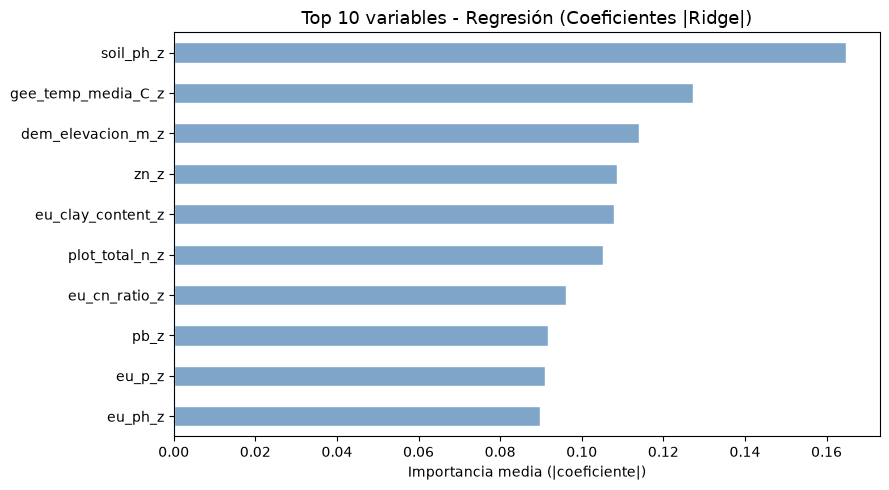

In [6]:
# Calculo de las variables mas relevantes
print("Calculando variables más relevantes...\n")

mas_relevantes_dict = {}
importancias_todas = pd.DataFrame(index=FEATURES_AUTORIZADAS)

for target_col in TARGETS:
    ruta = os.path.join(MODELS_DIR, f'ridge_prod_{target_col}.pkl')
    modelo = joblib.load(ruta)
    
    coefs_abs = pd.Series(np.abs(modelo.coef_), index=FEATURES_AUTORIZADAS)
    importancias_todas[target_col] = coefs_abs
    mas_relevantes_dict[target_col] = coefs_abs.nlargest(10).index.tolist()

df_mas_relevantes = pd.DataFrame(mas_relevantes_dict)

# Métrica Global
importancia_global = importancias_todas.mean(axis=1)
global_mas_relevantes = importancia_global.nlargest(10).index.tolist()
df_mas_relevantes.insert(0, 'GLOBAL_mas_RELEVANTES', global_mas_relevantes)

# IMPRESIÓN EN TEXTO PLANO
print("Top 10 variables más relevantes a nivel global:")
for i, var in enumerate(global_mas_relevantes, 1):
    print(f"{i:2d}. {var}")

print("\n" + "=" * 50)
print("Top 10 variables más relevantes por target:")
for target_col in TARGETS:
    print(f"\n--- Target: {target_col} ---")
    for i, var in enumerate(mas_relevantes_dict[target_col], 1):
        print(f"  {i:2d}. {var}")

# Grafico: barplot importancia de variables (top 10 global, por valor de coeficiente absoluto)
fig, ax = plt.subplots(figsize=(9, 5))
importancia_global.loc[global_mas_relevantes].sort_values().plot(
    kind='barh', ax=ax, color=PALETTE['blue'], edgecolor='white'
)
ax.set_title('Top 10 variables - Regresión (Coeficientes |Ridge|)', fontsize=13)
ax.set_xlabel('Importancia media (|coeficiente|)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 6.- Entrenamiento de produccion

La regresion lineal es determinista (no depende de semillas aleatorias), por lo que se entrena un unico modelo por variable objetivo. Cada modelo se guarda en disco en formato `.pkl`.

In [7]:
# SECCIÓN 6: Producción
print('Entrenamiento de produccion (un modelo por target con sus propios hiperparametros)...\n')

global_start = time.time()

for target_col in TARGETS:
    y = y_train[target_col].values
    
    mejores_params = REG_OPTIMAL_PARAMS_PER_TARGET[target_col]
    model = Ridge(**mejores_params, random_state=RANDOM_STATE)
    model.fit(X_train, y)
    
    ruta = os.path.join(MODELS_DIR, f'ridge_prod_{target_col}.pkl')
    joblib.dump(model, ruta)

print(f'Produccion completada. Modelos guardados: {len(TARGETS)}')

Entrenamiento de produccion (un modelo por target con sus propios hiperparametros)...

Produccion completada. Modelos guardados: 21


## 7.- Evaluacion final sobre eval.csv

Se usa `eval.csv` por primera vez para obtener una estimacion real del rendimiento en produccion. A continuacion se ejecuta un smoke test para verificar que el pipeline de carga e inferencia funciona correctamente.

**Interpretacion del indice Shannon H':** 
El modelo predice el indice de diversidad de Shannon, que va aproximadamente de `0.0` (sin diversidad) a `4.0-5.0` (alta diversidad biologica).

Evaluacion final sobre eval.csv

  Target                               R2     RMSE      MAE
-----------------------------------------------------------------
  nematode_shannon_z               0.0112   0.9821   0.7929
  macro_shannon_z                  0.1257   0.9391   0.8177
  earthworm_shannon_z              0.2395   0.8704   0.7094
  orib_shannon_z                   0.1137   1.0766   0.9075


  meso_shannon_z                  -0.2499   1.0918   0.9023
  coll_shannon_z                  -0.4998   0.7758   0.6426
  bac_shannon_z                   -0.0812   1.0413   0.7158
  fun_shannon_z                   -0.0161   1.1533   0.9503
  euk_shannon_z                    0.0407   0.9499   0.7011
  oomy_shannon_z                   0.0857   0.9996   0.7418
  cerc_shannon_z                   0.0155   0.8886   0.6332
  macro_order_richness_z           0.1521   0.8433   0.7105
  earthworm_richness_z             0.2789   0.7754   0.6143
  orib_species_richness_z          0.0921   1.1400   0.7670
  meso_species_richness_z         -0.0959   1.0097   0.7693
  coll_species_richness_z         -0.7341   0.6780   0.5409
  bac_asv_richness_z              -0.0761   1.1398   0.8335
  fun_asv_richness_z               0.0087   1.0731   0.8114
  euk_asv_richness_z               0.0400   0.7955   0.5775
  oomy_asv_richness_z              0.1035   0.9510   0.7711
  cerc_asv_richness_z              0.101

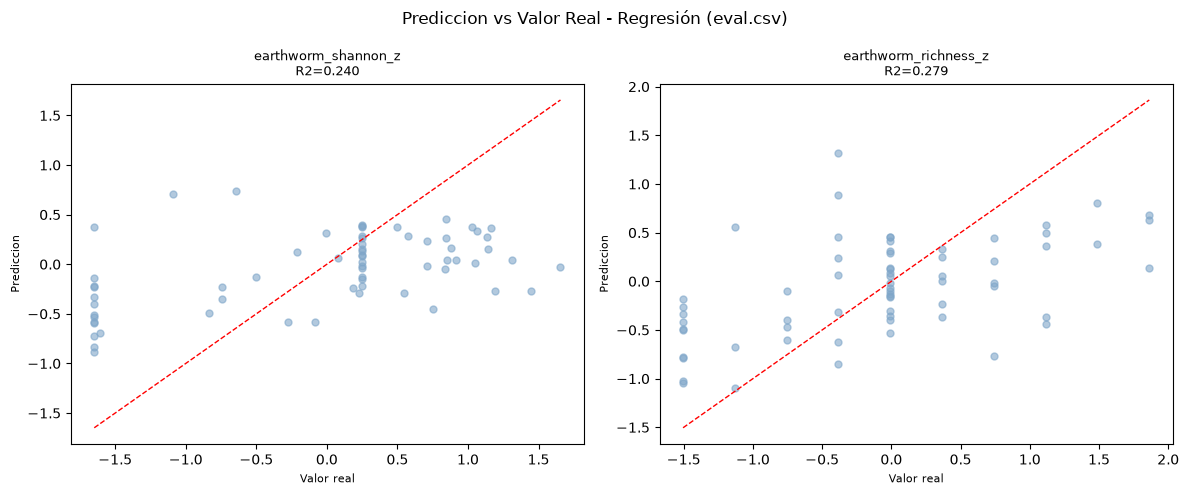

In [8]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Evaluacion final sobre todos los targets

print('Evaluacion final sobre eval.csv\n')

print(f'  {"Target":30} {"R2":>8} {"RMSE":>8} {"MAE":>8}')
print('-' * 65)

for test_target in TARGETS:
    ruta        = os.path.join(MODELS_DIR, f'ridge_prod_{test_target}.pkl')
    modelo_eval = joblib.load(ruta)
    y_pred_eval = modelo_eval.predict(X_eval)
    y_true_eval = y_eval[test_target].values

    r2   = r2_score(y_true_eval, y_pred_eval)
    rmse = np.sqrt(mean_squared_error(y_true_eval, y_pred_eval))
    mae  = mean_absolute_error(y_true_eval, y_pred_eval)
    print(f'  {test_target:30} {r2:8.4f} {rmse:8.4f} {mae:8.4f}')

print('-' * 65)


# Smoke test con datos reales
# Se prueban dos targets representativos: uno shannon y uno richness

print('\nSmoke test - Inferencia con datos reales')
print('-' * 65)

try:
    df_new_data      = X_eval.sample(n=3, random_state=RANDOM_STATE)
    indices_elegidos = df_new_data.index

    for test_target in ['earthworm_shannon_z', 'earthworm_richness_z']:
        print(f'\n  Target: {test_target}')
        print('  ' + '-' * 63)
        valores_reales = y_eval.loc[indices_elegidos, test_target].values

        ruta        = os.path.join(MODELS_DIR, f'ridge_prod_{test_target}.pkl')
        modelo_eval = joblib.load(ruta)
        pred        = modelo_eval.predict(df_new_data)
        for i, idx in enumerate(indices_elegidos):
            real_val = valores_reales[i]
            print(f'    Fila {idx:<4} | Prediccion: {pred[i]:.4f} | '
                  f'Valor Real: {real_val:.4f} | Error: {abs(pred[i]-real_val):.4f}')

    print('\nSmoke test superado. El pipeline funciona correctamente...')

except Exception as e:
    print(f'Error en el smoke test: {str(e)}')

# Grafico: scatter prediccion vs valor real 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, tgt in zip(axes, ['earthworm_shannon_z', 'earthworm_richness_z']):
    m  = joblib.load(os.path.join(MODELS_DIR, f'ridge_prod_{tgt}.pkl'))
    yp = m.predict(X_eval)
    yt = y_eval[tgt].values
    ax.scatter(yt, yp, alpha=0.6, s=25, color=PALETTE['blue'])
    lim = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lim, lim, 'r--', linewidth=1)
    ax.set_title(f'{tgt}\nR2={r2_score(yt, yp):.3f}', fontsize=9)
    ax.set_xlabel('Valor real', fontsize=8)
    ax.set_ylabel('Prediccion', fontsize=8)
plt.suptitle('Prediccion vs Valor Real - Regresión (eval.csv)', fontsize=12)
plt.tight_layout()
plt.show()